In [ ]:
#reading/writing JSON
import json
#plotting
import matplotlib.pyplot as plt
#calculating model metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
#calculating precision and recall
from sklearn.metrics import precision_score, recall_score,f1_score,confusion_matrix
#computing class weights
from sklearn.utils import compute_class_weight
#Generic Transformer model
from transformers import AutoModel
#Transformer model for classification tasks
from transformers import AutoModelForSequenceClassification
#Generic tokenizer
from transformers import AutoTokenizer
#Bert model for classification
from transformers import BertForSequenceClassification
#Bert tokenizer
from transformers import BertTokenizer
#Deberta model for classification
from transformers import DebertaForSequenceClassification
#Deberta tokenizer
from transformers import DebertaTokenizer
#reading CSV files
import csv
#network analysis
import networkx as nx
#arrays and math
import numpy as np
#dataframes
import pandas as pd
#PyTorch
import torch
#training
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [ ]:
!unzip -oq /content/contract-nli.zip -d /content/

In [ ]:
import os
os.listdir('/content/contract-nli')

['raw', 'TERMS', 'test.json', 'train.json', 'LICENSE', 'README.md', 'dev.json']

In [ ]:
import json
import pandas as pd

def parse_file(file_name):
    with open(file_name) as f:
        data = json.load(f)

    documents = data['documents']
    labels = data['labels']

    rows = []
    for doc in documents:
        doc_id = doc['id']
        text = doc['text']
        for annotation_key in doc['annotation_sets'][0]['annotations']:
            hyp_key = annotation_key
            label = doc['annotation_sets'][0]['annotations'][hyp_key]['choice']
            spans = doc['annotation_sets'][0]['annotations'][hyp_key]['spans']
            hyp = labels[hyp_key]['hypothesis']
            rows.append([doc_id, text, hyp, label, spans])

    df = pd.DataFrame(rows, columns=['doc_id', 'text', 'hypothesis', 'label', 'spans'])
    return df


# Convert train.json to train.csv
train_df = parse_file('/content/contract-nli/train.json')
train_df.to_csv('/content/contract-nli/train.csv', index=False)

# Convert dev.json to dev.csv
dev_df = parse_file('/content/contract-nli/dev.json')
dev_df.to_csv('/content/contract-nli/dev.csv', index=False)

# Convert test.json to test.csv
test_df = parse_file('/content/contract-nli/test.json')
test_df.to_csv('/content/contract-nli/test.csv', index=False)

print("Done!")

Done!


In [ ]:
import pandas as pd

train = pd.read_csv('/content/contract-nli/train.csv')
dev = pd.read_csv('/content/contract-nli/dev.csv')
test = pd.read_csv('/content/contract-nli/test.csv')

In [ ]:
print(train.shape)
print(dev.shape)
print(test.shape)

(7191, 5)
(1037, 5)
(2091, 5)


In [ ]:
train.head()

,doc_id,text,hypothesis,label,spans
0,34,NON-DISCLOSURE AND CONFIDENTIALITY AGREEMENT\n...,Receiving Party shall not reverse engineer any...,NotMentioned,[]
1,34,NON-DISCLOSURE AND CONFIDENTIALITY AGREEMENT\n...,Receiving Party shall destroy or return some C...,Entailment,"[39, 40]"
2,34,NON-DISCLOSURE AND CONFIDENTIALITY AGREEMENT\n...,Agreement shall not grant Receiving Party any ...,Entailment,[38]
3,34,NON-DISCLOSURE AND CONFIDENTIALITY AGREEMENT\n...,Receiving Party shall not disclose the fact th...,Entailment,[51]
4,34,NON-DISCLOSURE AND CONFIDENTIALITY AGREEMENT\n...,Confidential Information shall only include te...,NotMentioned,[]


In [ ]:
dev.head()

,doc_id,text,hypothesis,label,spans
0,3,OISAIR PROJECT\nTWO-WAY CONFIDENTIALITY AND NO...,Receiving Party shall not reverse engineer any...,Entailment,"[33, 39]"
1,3,OISAIR PROJECT\nTWO-WAY CONFIDENTIALITY AND NO...,Receiving Party shall destroy or return some C...,Entailment,[47]
2,3,OISAIR PROJECT\nTWO-WAY CONFIDENTIALITY AND NO...,Agreement shall not grant Receiving Party any ...,Entailment,[51]
3,3,OISAIR PROJECT\nTWO-WAY CONFIDENTIALITY AND NO...,Receiving Party shall not disclose the fact th...,Entailment,"[89, 90]"
4,3,OISAIR PROJECT\nTWO-WAY CONFIDENTIALITY AND NO...,Confidential Information shall only include te...,Contradiction,[17]


In [ ]:
test.head()

,doc_id,text,hypothesis,label,spans
0,1,NON-DISCLOSURE AGREEMENT\nRequired under JEA's...,Receiving Party shall not reverse engineer any...,NotMentioned,[]
1,1,NON-DISCLOSURE AGREEMENT\nRequired under JEA's...,Receiving Party shall destroy or return some C...,Entailment,"[84, 85, 86]"
2,1,NON-DISCLOSURE AGREEMENT\nRequired under JEA's...,Agreement shall not grant Receiving Party any ...,Entailment,[45]
3,1,NON-DISCLOSURE AGREEMENT\nRequired under JEA's...,Receiving Party shall not disclose the fact th...,NotMentioned,[]
4,1,NON-DISCLOSURE AGREEMENT\nRequired under JEA's...,Confidential Information shall only include te...,Contradiction,"[25, 32]"


In [ ]:
train.info()
dev.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7191 entries, 0 to 7190
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   doc_id      7191 non-null   int64 
 1   text        7191 non-null   object
 2   hypothesis  7191 non-null   object
 3   label       7191 non-null   object
 4   spans       7191 non-null   object
dtypes: int64(1), object(4)
memory usage: 281.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   doc_id      1037 non-null   int64 
 1   text        1037 non-null   object
 2   hypothesis  1037 non-null   object
 3   label       1037 non-null   object
 4   spans       1037 non-null   object
dtypes: int64(1), object(4)
memory usage: 40.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2091 entries, 0 to 2090
Data columns (total 5 columns):
 #   Column      No

EDA

Wordcloud Generates a word cloud from the most frequent words in the text. Gives a quick visual of the main topics.

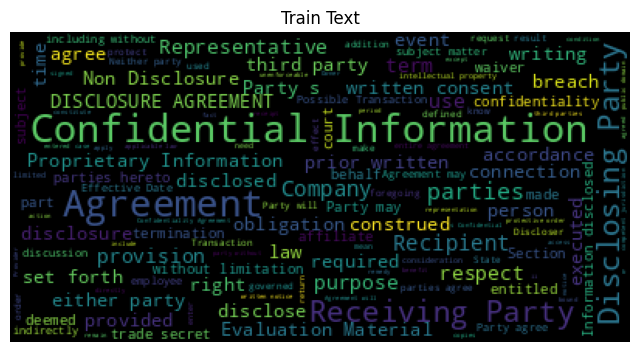

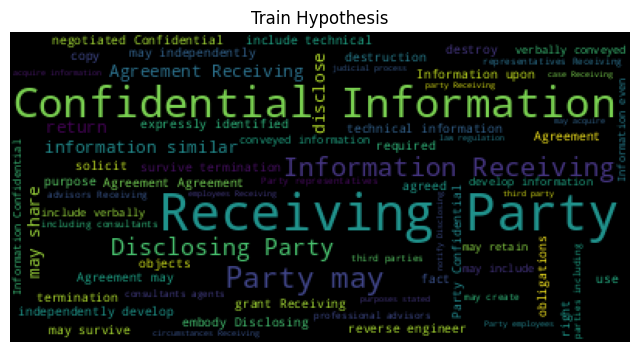

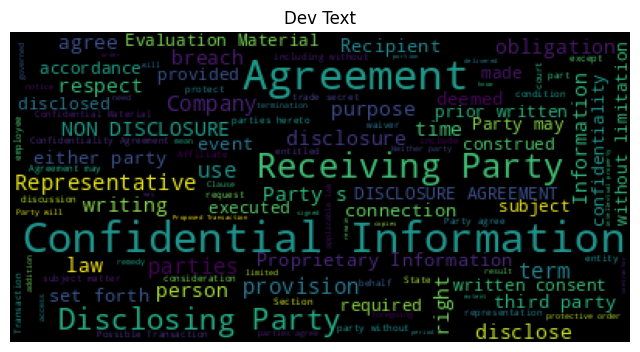

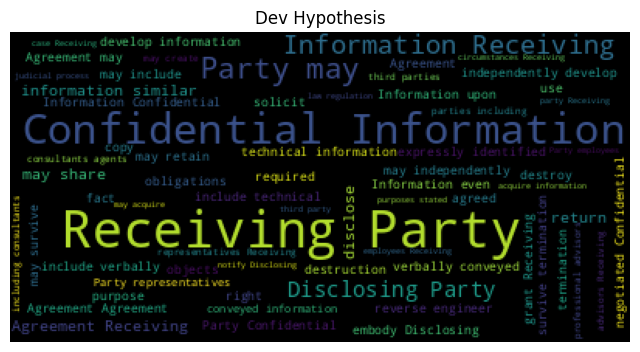

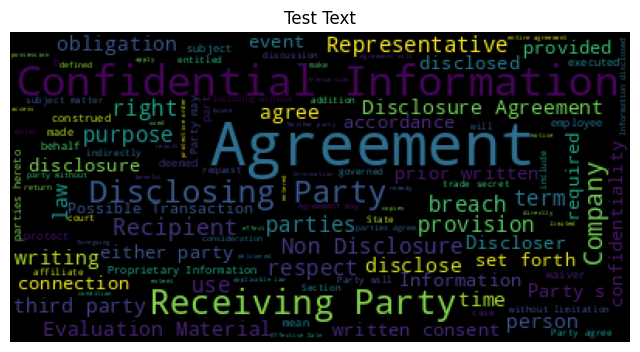

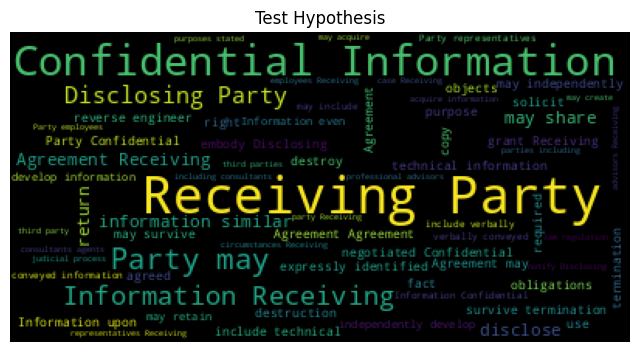

In [ ]:
def plot_word_cloud(text, title):
    wordcloud = WordCloud().generate(text)
    plt.figure(figsize=(8,8))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title)

# Train
plot_word_cloud(" ".join(train.text.tolist()), "Train Text")
plt.show()
plot_word_cloud(" ".join(train.hypothesis.tolist()), "Train Hypothesis")
plt.show()

# Dev
plot_word_cloud(" ".join(dev.text.tolist()), "Dev Text")
plt.show()
plot_word_cloud(" ".join(dev.hypothesis.tolist()), "Dev Hypothesis")
plt.show()

# Test
plot_word_cloud(" ".join(test.text.tolist()), "Test Text")
plt.show()
plot_word_cloud(" ".join(test.hypothesis.tolist()), "Test Hypothesis")
plt.show()

Bar plot of frequency Plots the frequency of the top N words as a bar chart. Shows which words are most common.


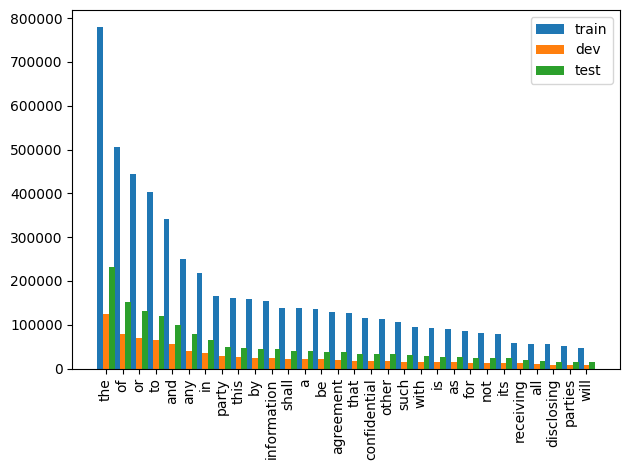

In [ ]:
df = [train, dev, test]
cols = ['text', 'hypothesis']
names = ['train', 'dev', 'test']

# Plot text
indexes = np.arange(30)
bar_width = 0.35

fig, ax = plt.subplots()

for i, d in enumerate(df):
    freq_text = Counter(" ".join(d['text']).lower().split()).most_common(30)
    labels = [t[0] for t in freq_text]
    values = [t[1] for t in freq_text]
    labels = labels[:30]
    values = values[:30]
    ax.bar(indexes + bar_width*i, values, bar_width, label=names[i])

ax.set_xticks(indexes + bar_width)
ax.set_xticklabels(labels, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

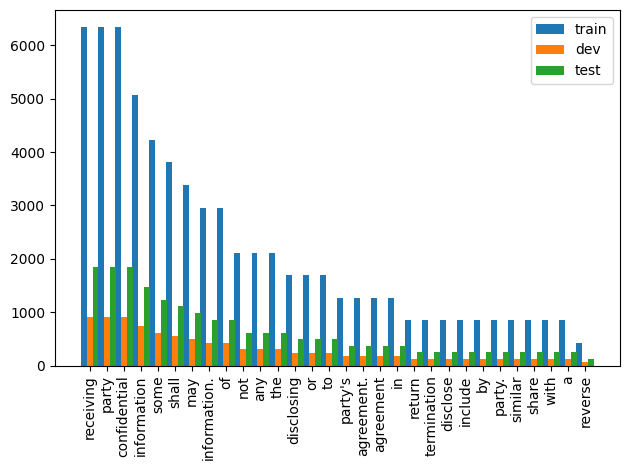

In [ ]:
# Plot hypothesis
indexes = np.arange(30)
fig, ax = plt.subplots()

for i, d in enumerate(df):
    freq_hyp = Counter(" ".join(d['hypothesis']).lower().split()).most_common(30)
    labels = [t[0] for t in freq_hyp]
    values = [t[1] for t in freq_hyp]
    labels = labels[:30]
    values = values[:30]
    ax.bar(indexes + bar_width*i, values, bar_width, label=names[i])

ax.set_xticks(indexes + bar_width)
ax.set_xticklabels(labels, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

the text column contains more common function words like 'the', 'of', 'and', while the hypothesis column contains more domain-specific words like 'receiving', 'agreement', and 'information.'.


Check the overall class distribution and label entropy to assess any imbalance.

In [ ]:
labels_train = train['label'].value_counts()
labels_train

,count
label,
Entailment,3530
NotMentioned,2820
Contradiction,841


In [ ]:
# Train set
counts_train = train['label'].value_counts()
entropy_train = compute_class_weight('balanced',
                                    classes=counts_train.index.to_numpy(),
                                    y=train['label'])

print('Train set:')
print(f'Distribution: {counts_train}')
print(f'Entropy: {entropy_train}')

# Dev set
counts_dev = dev['label'].value_counts()
entropy_dev = compute_class_weight('balanced',
                                   classes=counts_dev.index.to_numpy(),
                                   y=dev['label'])

print('Dev set:')
print(f'Distribution: {counts_dev}')
print(f'Entropy: {entropy_dev}')

# Test set
counts_test = test['label'].value_counts()
entropy_test = compute_class_weight('balanced',
                                    classes=counts_test.index.to_numpy(),
                                    y=test['label'])

print('Test set:')
print(f'Distribution: {counts_test}')
print(f'Entropy: {entropy_test}')

Train set:
Distribution: label
Entailment       3530
NotMentioned     2820
Contradiction     841
Name: count, dtype: int64
Entropy: [0.67903683 0.85       2.85017836]
Dev set:
Distribution: label
Entailment       519
NotMentioned     423
Contradiction     95
Name: count, dtype: int64
Entropy: [0.66602441 0.81717888 3.63859649]
Test set:
Distribution: label
Entailment       968
NotMentioned     903
Contradiction    220
Name: count, dtype: int64
Entropy: [0.72004132 0.77187154 3.16818182]


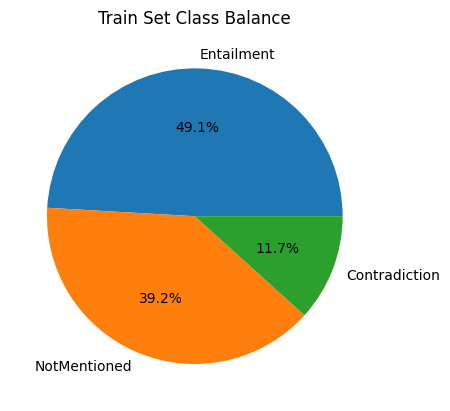

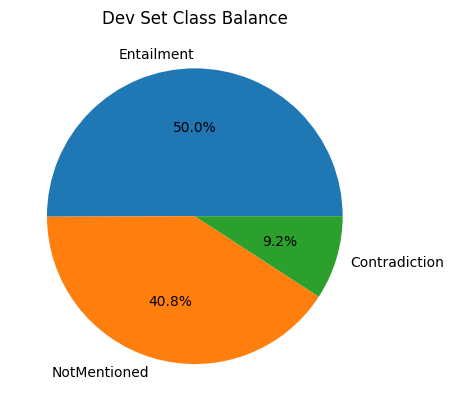

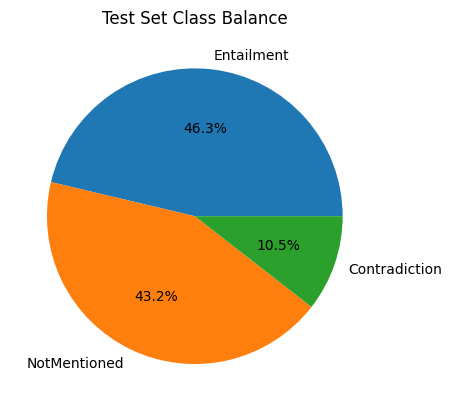

In [ ]:
# Train set
labels_train = train['label'].value_counts()
entailment_train = labels_train['Entailment']
contradiction_train = labels_train['Contradiction']
NotMentioned_train = labels_train['NotMentioned']

# Dev set
labels_dev = dev['label'].value_counts()
entailment_dev = labels_dev['Entailment']
contradiction_dev = labels_dev['Contradiction']
NotMentioned_dev = labels_dev['NotMentioned']

# Test set
labels_test = test['label'].value_counts()
entailment_test = labels_test['Entailment']
contradiction_test = labels_test['Contradiction']
NotMentioned_test = labels_test['NotMentioned']

# Pie chart for train set
plt.pie([entailment_train, NotMentioned_train, contradiction_train], labels=['Entailment', 'NotMentioned', 'Contradiction'],
   autopct = '%1.1f%%')
plt.title("Train Set Class Balance")
plt.show()

# Pie chart for dev set
plt.pie([entailment_dev, NotMentioned_dev, contradiction_dev], labels=['Entailment', 'NotMentioned', 'Contradiction'],
   autopct = '%1.1f%%')
plt.title("Dev Set Class Balance")
plt.show()

# Pie chart for test set
plt.pie([entailment_test, NotMentioned_test, contradiction_test], labels=['Entailment', 'NotMentioned', 'Contradiction'],
   autopct = '%1.1f%%')
plt.title("Test Set Class Balance")
plt.show()

In [ ]:
label_mapping = {"NotMentioned": 0, "Entailment": 1, "Contradiction": 2}

train_labels = [label_mapping[label] for label in train['label'].tolist()]
valid_labels = [label_mapping[label] for label in dev['label'].tolist()]
test_labels = [label_mapping[label] for label in test['label'].tolist()]

1- DeBERTa


In [ ]:
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

In [ ]:
from transformers import DataCollatorWithPadding
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Tokenization function
def tokenize_data(data):
    return tokenizer(
        text=data['text'].tolist(),
        text_pair=data['hypothesis'].tolist(),
        truncation=True,
        max_length=512
    )


# Dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# Evaluation metrics
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    true_labels = p.label_ids

    # Accuracy
    accuracy = accuracy_score(true_labels, preds)

    # Weighted metrics (handles imbalance)
    precision_weighted = precision_score(
        true_labels,
        preds,
        average='weighted'
    )

    recall_weighted = recall_score(
        true_labels,
        preds,
        average='weighted'
    )

    f1_weighted = f1_score(
        true_labels,
        preds,
        average='weighted'
    )

    # Macro F1 (treats all classes equally)
    f1_macro = f1_score(
        true_labels,
        preds,
        average='macro'
    )

    # Confusion matrix
    cm = confusion_matrix(true_labels, preds)

    # Class-wise performance
    report = classification_report(
        true_labels,
        preds,
        output_dict=True
    )

    return {
        "accuracy": accuracy,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "confusion_matrix": cm.tolist(),
        "classification_report": report
    }

In [ ]:
class ContractNLIDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(value[idx]) for key, value in self.encodings.items()}
        # Here we ensure the label is an integer tensor
        item['labels'] = torch.tensor(int(self.labels[idx]))
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_encodings = tokenize_data(train)
valid_encodings = tokenize_data(dev)
test_encodings = tokenize_data(test)

In [ ]:
train_dataset = ContractNLIDataset(
    train_encodings,
    train_labels
)

valid_dataset = ContractNLIDataset(
    valid_encodings,
    valid_labels
)

test_dataset = ContractNLIDataset(
    test_encodings,
    test_labels
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print(class_weights)

tensor([0.8500, 0.6790, 2.8502])


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=5,
    learning_rate=2e-5,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,

    weight_decay=0.01,

    warmup_ratio=0.1,          # Better than fixed warmup_steps
    lr_scheduler_type="linear",

    fp16=True,

    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir="./logs",
    logging_steps=10,

    seed=42,
    save_total_limit=1,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    torch_dtype=torch.float32
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.den

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
device = model.device

batch = train_dataset[0]

inputs = {
    "input_ids": batch["input_ids"].unsqueeze(0).to(device),
    "attention_mask": batch["attention_mask"].unsqueeze(0).to(device),
    "labels": batch["labels"].unsqueeze(0).to(device),
}

outputs = model(**inputs)

print("Loss:", outputs.loss)
print("Logits:", outputs.logits)

Loss: tensor(1.0919, grad_fn=<NllLossBackward0>)
Logits: tensor([[-0.0951, -0.0490, -0.1646]], grad_fn=<AddmmBackward0>)


In [ ]:
from transformers import Trainer
import torch
import torch.nn as nn


class WeightedTrainer(Trainer):

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            raise ValueError("class_weights must be provided.")

        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_fn(logits, labels)

        if return_outputs:
            return loss, outputs

        return loss


trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
print(model.dtype)

torch.float32


In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro,Confusion Matrix,Classification Report
1,2.741872,0.742442,0.701061,0.720831,0.701061,0.703784,0.657025,"[[329, 57, 37], [156, 343, 20], [23, 17, 55]]","{'0': {'precision': 0.6476377952755905, 'recall': 0.7777777777777778, 'f1-score': 0.706766917293233, 'support': 423.0}, '1': {'precision': 0.8225419664268585, 'recall': 0.6608863198458574, 'f1-score': 0.7329059829059829, 'support': 519.0}, '2': {'precision': 0.49107142857142855, 'recall': 0.5789473684210527, 'f1-score': 0.5314009661835749, 'support': 95.0}, 'accuracy': 0.7010607521697203, 'macro avg': {'precision': 0.6537503967579592, 'recall': 0.6725371553482292, 'f1-score': 0.6570246221275969, 'support': 1037.0}, 'weighted avg': {'precision': 0.7208311028846673, 'recall': 0.7010607521697203, 'f1-score': 0.7037837058155085, 'support': 1037.0}}"
2,3.178518,0.708501,0.709740,0.716998,0.709740,0.712484,0.657621,"[[287, 89, 47], [107, 393, 19], [15, 24, 56]]","{'0': {'precision': 0.7017114914425427, 'recall': 0.6784869976359338, 'f1-score': 0.6899038461538461, 'support': 423.0}, '1': {'precision': 0.7766798418972332, 'recall': 0.7572254335260116, 'f1-score': 0.7668292682926829, 'support': 519.0}, '2': {'precision': 0.45901639344262296, 'recall': 0.5894736842105263, 'f1-score': 0.5161290322580645, 'support': 95.0}, 'accuracy': 0.7097396335583414, 'macro avg': {'precision': 0.645802575594133, 'recall': 0.6750620384574906, 'f1-score': 0.6576207155681978, 'support': 1037.0}, 'weighted avg': {'precision': 0.7169984148523709, 'recall': 0.7097396335583414, 'f1-score': 0.7124840648326861, 'support': 1037.0}}"
3,2.161361,0.699292,0.712633,0.732062,0.712633,0.717147,0.672522,"[[271, 102, 50], [83, 396, 40], [13, 10, 72]]","{'0': {'precision': 0.7384196185286104, 'recall': 0.640661938534279, 'f1-score': 0.6860759493670886, 'support': 423.0}, '1': {'precision': 0.7795275590551181, 'recall': 0.7630057803468208, 'f1-score': 0.7711781888997079, 'support': 519.0}, '2': {'precision': 0.4444444444444444, 'recall': 0.7578947368421053, 'f1-score': 0.5603112840466926, 'support': 95.0}, 'accuracy': 0.712632594021215, 'macro avg': {'precision': 0.6541305406760577, 'recall': 0.7205208185744016, 'f1-score': 0.6725218074378297, 'support': 1037.0}, 'weighted avg': {'precision': 0.7320622218027296, 'recall': 0.712632594021215, 'f1-score': 0.7171467488964923, 'support': 1037.0}}"
4,2.045483,0.675089,0.718419,0.745132,0.718419,0.725619,0.679352,"[[291, 77, 55], [97, 379, 43], [11, 9, 75]]","{'0': {'precision': 0.7293233082706767, 'recall': 0.6879432624113475, 'f1-score': 0.708029197080292, 'support': 423.0}, '1': {'precision': 0.8150537634408602, 'recall': 0.7302504816955684, 'f1-score': 0.7703252032520326, 'support': 519.0}, '2': {'precision': 0.43352601156069365, 'recall': 0.7894736842105263, 'f1-score': 0.5597014925373134, 'support': 95.0}, 'accuracy': 0.7184185149469624, 'macro avg': {'precision': 0.6593010277574102, 'recall': 0.7358891427724807, 'f1-score': 0.6793519642898792, 'support': 1037.0}, 'weighted avg': {'precision': 0.7451317586524286, 'recall': 0.7184185149469624, 'f1-score': 0.7256188742949017, 'support': 1037.0}}"
5,2.348762,0.718115,0.721311,0.742716,0.721311,0.727116,0.677472,"[[281, 92, 50], [81, 396, 42], [15, 9, 71]]","{'0': {'precision': 0.7453580901856764, 'recall': 0.6643026004728132, 'f1-score': 0.7025, 'support': 423.0}, '1': {'precision': 0.7967806841046278, 'recall': 0.7630057803468208, 'f1-score': 0.7795275590551181, 'support': 519.0}, '2': {'precision': 0.43558282208588955, 'recall': 0.7473684210526316, 'f1-score': 0.5503875968992248, 'support': 95.0}, 'accuracy': 0.7213114754098361, 'macro avg': {'precision': 0.6592405321253979, 'recall': 0.7248922672907553, 'f1-score': 0.6774717186514477, 'support': 1037.0}, 'weighted avg': {'precision': 0.7427155403056919, 'recall': 0.7213114754098361, 'f1-score': 0.7271158388187393, 'support': 1037.0}}"


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4495, training_loss=2.7137442577137167, metrics={'train_runtime': 3835.9276, 'train_samples_per_second': 9.373, 'train_steps_per_second': 1.172, 'total_flos': 9460145362028400.0, 'train_loss': 2.7137442577137167, 'epoch': 5.0})

In [ ]:
# Save the BEST model (because load_best_model_at_end=True)

SAVE_PATH = "/content/deberta_contractnli_best"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Best model saved successfully!")
print("Best validation metric:", trainer.state.best_metric)
print("Best checkpoint:", trainer.state.best_model_checkpoint)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved successfully!
Best validation metric: 0.6793519642898792
Best checkpoint: ./results/checkpoint-3596


In [ ]:
import shutil

shutil.make_archive(
    "/content/deberta_contractnli_best",
    "zip",
    SAVE_PATH
)

print("ZIP file created!")

ZIP file created!


In [ ]:
from google.colab import files

files.download("/content/deberta_contractnli_best.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate the BEST model on the test set

test_results = trainer.predict(test_dataset)

print("Test Metrics")
for key, value in test_results.metrics.items():
    print(f"{key}: {value}")

Test Metrics
test_loss: 0.6910471320152283
test_accuracy: 0.7230989956958394
test_precision_weighted: 0.7458815344619985
test_recall_weighted: 0.7230989956958394
test_f1_weighted: 0.7289000202638701
test_f1_macro: 0.6907129981590195
test_confusion_matrix: [[620, 167, 116], [164, 720, 84], [26, 22, 172]]
test_classification_report: {'0': {'precision': 0.7654320987654321, 'recall': 0.6866002214839424, 'f1-score': 0.7238762405137186, 'support': 903.0}, '1': {'precision': 0.7920792079207921, 'recall': 0.743801652892562, 'f1-score': 0.7671816728822589, 'support': 968.0}, '2': {'precision': 0.46236559139784944, 'recall': 0.7818181818181819, 'f1-score': 0.581081081081081, 'support': 220.0}, 'accuracy': 0.7230989956958394, 'macro avg': {'precision': 0.6732922993613579, 'recall': 0.7374066853982287, 'f1-score': 0.6907129981590195, 'support': 2091.0}, 'weighted avg': {'precision': 0.7458815344619985, 'recall': 0.7230989956958394, 'f1-score': 0.7289000202638701, 'support': 2091.0}}
test_runtime: 

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictions
predictions = np.argmax(test_results.predictions, axis=1)
true_labels = test_results.label_ids

# Metrics
print(f"Accuracy           : {accuracy_score(true_labels, predictions):.4f}")
print(f"Precision Weighted : {precision_score(true_labels, predictions, average='weighted'):.4f}")
print(f"Recall Weighted    : {recall_score(true_labels, predictions, average='weighted'):.4f}")
print(f"F1-score Weighted  : {f1_score(true_labels, predictions, average='weighted'):.4f}")
print(f"Macro F1-score     : {f1_score(true_labels, predictions, average='macro'):.4f}")

# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, predictions))

Accuracy           : 0.7231
Precision Weighted : 0.7459
Recall Weighted    : 0.7231
F1-score Weighted  : 0.7289
Macro F1-score     : 0.6907

Confusion Matrix:
[[620 167 116]
 [164 720  84]
 [ 26  22 172]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.69      0.72       903
           1       0.79      0.74      0.77       968
           2       0.46      0.78      0.58       220

    accuracy                           0.72      2091
   macro avg       0.67      0.74      0.69      2091
weighted avg       0.75      0.72      0.73      2091



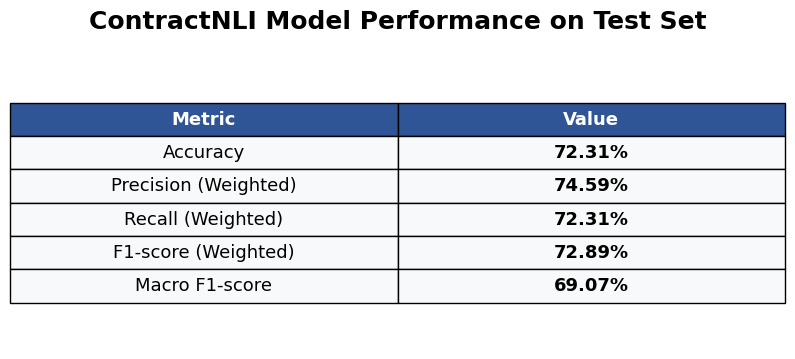

Saved as: contractnli_test_metrics.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Final Test Metrics
metrics = {
    "Metric": [
        "Accuracy",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-score (Weighted)",
        "Macro F1-score"
    ],
    "Value": [
        "72.31%",
        "74.59%",
        "72.31%",
        "72.89%",
        "69.07%"
    ]
}

df = pd.DataFrame(metrics)

# Create figure
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.25, 2.0)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2F5597")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F8F9FA")
        if col == 1:
            cell.set_text_props(weight="bold")

plt.title(
    "ContractNLI Model Performance on Test Set",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.savefig(
    "contractnli_test_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as: contractnli_test_metrics.png")

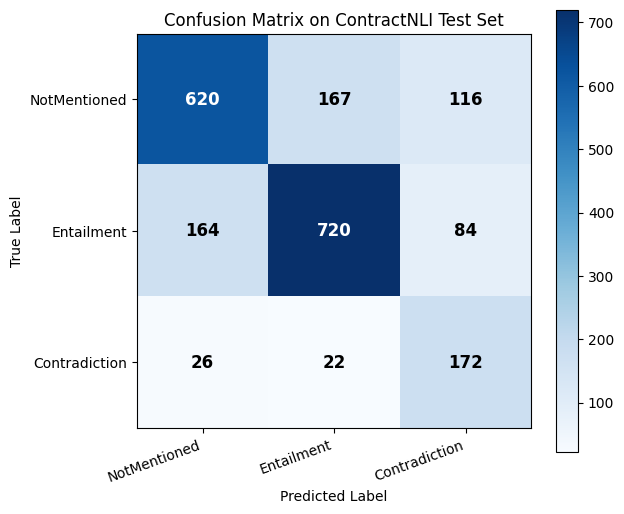

Saved as ContractNLI_Confusion_Matrix.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = np.array([
    [620, 167, 116],
    [164, 720, 84],
    [26, 22, 172]
])

class_names = ["NotMentioned", "Entailment", "Contradiction"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

# Labels
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted Label",
    ylabel="True Label",
    title="Confusion Matrix on ContractNLI Test Set"
)

plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# Write values inside cells
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=12,
            fontweight="bold"
        )

plt.tight_layout()

plt.savefig(
    "ContractNLI_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as ContractNLI_Confusion_Matrix.png")

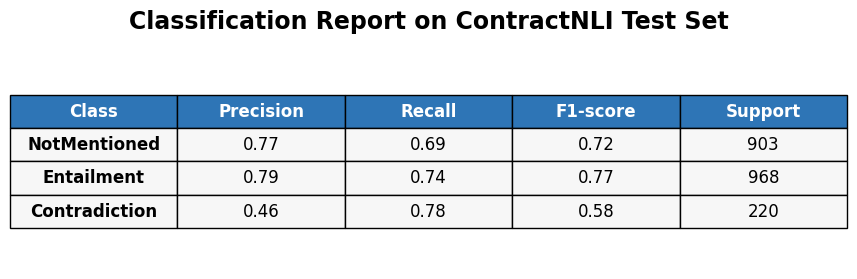

Saved as ContractNLI_Classification_Report.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Classification Report
report = pd.DataFrame({
    "Class": ["NotMentioned", "Entailment", "Contradiction"],
    "Precision": [0.77, 0.79, 0.46],
    "Recall": [0.69, 0.74, 0.78],
    "F1-score": [0.72, 0.77, 0.58],
    "Support": [903, 968, 220]
})

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")

table = ax.table(
    cellText=report.values,
    colLabels=report.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

# Style
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E75B6")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#F7F7F7")
        if col == 0:
            cell.set_text_props(weight="bold")

plt.title(
    "Classification Report on ContractNLI Test Set",
    fontsize=17,
    fontweight="bold",
    pad=18
)

plt.savefig(
    "ContractNLI_Classification_Report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as ContractNLI_Classification_Report.png")

In [ ]:
!ls -lh /content

total 623M
drwxr-xr-x 3 root root 4.0K Aug  8 04:40 contract-nli
-rw-r--r-- 1 root root  63M Aug  8 04:31 contract-nli.zip
drwxr-xr-x 3 root root 4.0K Aug  8 04:43 deberta_contractnli_best
-rw-r--r-- 1 root root 560M Aug  8 04:37 deberta_contractnli_best.zip
drwxr-xr-x 2 root root 4.0K Aug  8 04:43 results
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [ ]:
!mkdir -p /content/deberta_contractnli_best
!unzip -o "/content/deberta_contractnli_best.zip" -d "/content/deberta_contractnli_best"

Archive:  /content/deberta_contractnli_best.zip
  inflating: /content/deberta_contractnli_best/deberta_contractnli_best/config.json  
  inflating: /content/deberta_contractnli_best/deberta_contractnli_best/model.safetensors  
  inflating: /content/deberta_contractnli_best/deberta_contractnli_best/tokenizer.json  
  inflating: /content/deberta_contractnli_best/deberta_contractnli_best/tokenizer_config.json  
  inflating: /content/deberta_contractnli_best/deberta_contractnli_best/training_args.bin  


In [ ]:
model_path = "/content/deberta_contractnli_best/deberta_contractnli_best"

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
val_predictions = trainer.predict(valid_dataset)

In [ ]:
val_predictions

PredictionOutput(predictions=array([[ 2.9921875 ,  0.32421875, -3.5722656 ],
       [ 1.9355469 ,  1.5214844 , -3.0410156 ],
       [-0.33569336,  3.4511719 , -2.1015625 ],
       ...,
       [-0.63134766,  3.5507812 , -1.9472656 ],
       [-1.0566406 ,  3.5292969 , -1.5048828 ],
       [-0.8671875 ,  3.578125  , -1.7753906 ]], dtype=float32), label_ids=array([1, 1, 1, ..., 1, 1, 2]), metrics={'test_loss': 0.6750888824462891, 'test_model_preparation_time': 0.0321, 'test_accuracy': 0.7184185149469624, 'test_precision_weighted': 0.7451317586524286, 'test_recall_weighted': 0.7184185149469624, 'test_f1_weighted': 0.7256188742949017, 'test_f1_macro': 0.6793519642898792, 'test_confusion_matrix': [[291, 77, 55], [97, 379, 43], [11, 9, 75]], 'test_classification_report': {'0': {'precision': 0.7293233082706767, 'recall': 0.6879432624113475, 'f1-score': 0.708029197080292, 'support': 423.0}, '1': {'precision': 0.8150537634408602, 'recall': 0.7302504816955684, 'f1-score': 0.7703252032520326, 'supp

In [ ]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert logits to probabilities
logits = val_predictions.predictions
probs = softmax(logits, axis=1)

# Probability of contradiction class (label = 2)
contradiction_probs = probs[:, 2]

# True labels
true_labels = val_predictions.label_ids

best_threshold = None
best_f1 = 0

print(f"{'Threshold':<10}{'Precision':<12}{'Recall':<10}{'F1':<10}")

for threshold in np.arange(0.10, 0.96, 0.05):

    preds = np.argmax(probs, axis=1)

    # Override to contradiction if probability exceeds threshold
    preds[contradiction_probs >= threshold] = 2

    y_true = (true_labels == 2).astype(int)
    y_pred = (preds == 2).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{threshold:<10.2f}{precision:<12.4f}{recall:<10.4f}{f1:<10.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold


Threshold Precision   Recall    F1        
0.10      0.3320      0.8842    0.4828    
0.15      0.3609      0.8737    0.5108    
0.20      0.3756      0.8737    0.5253    
0.25      0.3821      0.8526    0.5277    
0.30      0.3980      0.8421    0.5405    
0.35      0.4021      0.8211    0.5398    
0.40      0.4208      0.8105    0.5540    
0.45      0.4310      0.7895    0.5576    
0.50      0.4335      0.7895    0.5597    
0.55      0.4335      0.7895    0.5597    
0.60      0.4335      0.7895    0.5597    
0.65      0.4335      0.7895    0.5597    
0.70      0.4335      0.7895    0.5597    
0.75      0.4335      0.7895    0.5597    
0.80      0.4335      0.7895    0.5597    
0.85      0.4335      0.7895    0.5597    
0.90      0.4335      0.7895    0.5597    
0.95      0.4335      0.7895    0.5597    


"My model outputs probabilities rather than final decisions, so I tuned the decision threshold using the validation set instead of automatically using the default threshold of 0.5. Since the objective of my project is to detect contradictions in legal documents, I prioritized maintaining high recall because missing a genuine contradiction can be more costly than reviewing an additional false positive. I evaluated multiple thresholds on the validation set and found that a threshold of 0.40 provided a good trade-off between precision and recall. It achieved 42.08% precision, 81.05% recall, and an F1-score of 55.40%, compared with 43.35% precision, 78.95% recall, and 55.97% F1 at 0.50. Although 0.50 had a marginally higher F1-score, I selected 0.40 because it provides higher contradiction recall with only a small decrease in F1, which better aligns with the objective of finding potential contradictions. After selecting the threshold on the validation set, I kept it fixed and evaluated the model once on the test set to obtain an unbiased estimate of performance."


In [ ]:
from transformers import AutoModelForSequenceClassification
import torch

model_path = "/content/deberta_contractnli_best/deberta_contractnli_best"

saved_model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=3,
    torch_dtype=torch.float32
)

print("Saved model loaded.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Saved model loaded.


In [ ]:
saved_trainer = WeightedTrainer(
    model=saved_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

print("Saved-model trainer ready.")

Saved-model trainer ready.


In [ ]:
saved_test_output = saved_trainer.predict(test_dataset)

print("Saved model test prediction completed.")

Saved model test prediction completed.


In [ ]:
print("Saved Model Test Metrics:\n")

for key, value in saved_test_output.metrics.items():
    print(f"{key}: {value}")

Saved Model Test Metrics:

test_loss: 0.6910471320152283
test_model_preparation_time: 0.0077
test_accuracy: 0.7230989956958394
test_precision_weighted: 0.7458815344619985
test_recall_weighted: 0.7230989956958394
test_f1_weighted: 0.7289000202638701
test_f1_macro: 0.6907129981590195
test_confusion_matrix: [[620, 167, 116], [164, 720, 84], [26, 22, 172]]
test_classification_report: {'0': {'precision': 0.7654320987654321, 'recall': 0.6866002214839424, 'f1-score': 0.7238762405137186, 'support': 903.0}, '1': {'precision': 0.7920792079207921, 'recall': 0.743801652892562, 'f1-score': 0.7671816728822589, 'support': 968.0}, '2': {'precision': 0.46236559139784944, 'recall': 0.7818181818181819, 'f1-score': 0.581081081081081, 'support': 220.0}, 'accuracy': 0.7230989956958394, 'macro avg': {'precision': 0.6732922993613579, 'recall': 0.7374066853982287, 'f1-score': 0.6907129981590195, 'support': 2091.0}, 'weighted avg': {'precision': 0.7458815344619985, 'recall': 0.7230989956958394, 'f1-score': 0.72

In [ ]:
from scipy.special import softmax
import numpy as np

saved_logits = saved_test_output.predictions

saved_probs = softmax(saved_logits, axis=1)

saved_true = saved_test_output.label_ids

print("Probabilities calculated.")
print("Shape:", saved_probs.shape)

Probabilities calculated.
Shape: (2091, 3)


In [ ]:
threshold = 0.40

# Normal argmax prediction
saved_pred = np.argmax(saved_probs, axis=1)

# Contradiction = class 2
contradiction_probs = saved_probs[:, 2]

# Apply threshold
saved_pred[contradiction_probs >= threshold] = 2

print("Threshold used:", threshold)
print("Number predicted as Contradiction:",
      np.sum(saved_pred == 2))

Threshold used: 0.4
Number predicted as Contradiction: 395


In [ ]:
accuracy = accuracy_score(saved_true, saved_pred)

precision_weighted = precision_score(
    saved_true,
    saved_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    saved_true,
    saved_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    saved_true,
    saved_pred,
    average="weighted",
    zero_division=0
)

f1_macro = f1_score(
    saved_true,
    saved_pred,
    average="macro",
    zero_division=0
)

cm = confusion_matrix(saved_true, saved_pred)

print("Accuracy:", accuracy)
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1:", f1_weighted)
print("Macro F1:", f1_macro)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        saved_true,
        saved_pred,
        zero_division=0
    )
)

Accuracy: 0.719273075083692
Weighted Precision: 0.746682862334595
Weighted Recall: 0.719273075083692
Weighted F1: 0.7259337004463342
Macro F1: 0.6878997904252424

Confusion Matrix:
[[612 164 127]
 [164 714  90]
 [ 23  19 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       903
           1       0.80      0.74      0.77       968
           2       0.45      0.81      0.58       220

    accuracy                           0.72      2091
   macro avg       0.67      0.74      0.69      2091
weighted avg       0.75      0.72      0.73      2091



MoritzLaurer

In [ ]:
label_mapping = {
    "NotMentioned": 0,
    "Entailment": 1,
    "Contradiction": 2
}

train_labels = [
    label_mapping[label]
    for label in train["label"].tolist()
]

valid_labels = [
    label_mapping[label]
    for label in dev["label"].tolist()
]

test_labels = [
    label_mapping[label]
    for label in test["label"].tolist()
]

In [ ]:
model_name1 = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)

config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [ ]:
from transformers import DataCollatorWithPadding
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np


# Tokenization function
def tokenize_data(data):
   return tokenizer1(
    text=data["text"].tolist(),
    text_pair=data["hypothesis"].tolist(),
    truncation=True,
    max_length=512,
    padding=False
)


# Dynamic padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer1
)


# Evaluation metrics
def compute_metrics(p):

    preds = np.argmax(p.predictions, axis=1)
    true_labels = p.label_ids

    accuracy = accuracy_score(
        true_labels,
        preds
    )

    precision_weighted = precision_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        true_labels,
        preds,
        average="macro",
        zero_division=0
    )

    # Contradiction class (label = 2)
    contradiction_f1 = f1_score(
        true_labels,
        preds,
        labels=[2],
        average="macro",
        zero_division=0
    )

    cm = confusion_matrix(
        true_labels,
        preds
    )

    report = classification_report(
        true_labels,
        preds,
        output_dict=True,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "contradiction_f1": contradiction_f1,
        "confusion_matrix": cm.tolist(),
        "classification_report": report
    }

In [ ]:
class ContractNLIDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            int(self.labels[idx]),
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_encodings = tokenize_data(train)
valid_encodings = tokenize_data(dev)
test_encodings = tokenize_data(test)

In [ ]:
train_dataset = ContractNLIDataset(
    train_encodings,
    train_labels
)

valid_dataset = ContractNLIDataset(
    valid_encodings,
    valid_labels
)

test_dataset = ContractNLIDataset(
    test_encodings,
    test_labels
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn
from transformers import Trainer

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:", class_weights)


class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fn(
            logits,
            labels
        )

        return (loss, outputs) if return_outputs else loss

Class weights: tensor([0.8500, 0.6790, 2.8502])


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_moritz",

    # Training
    num_train_epochs=5,
    learning_rate=1e-5,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=8,

    # Regularization
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,

    # Mixed precision
    fp16=True,
    bf16=False,

    # Evaluation & Checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    # Logging
    logging_dir="./logs_moritz",
    logging_steps=10,
    report_to="none",

    # Optimizer & Scheduler
    optim="adamw_torch",
    lr_scheduler_type="cosine",

    # Reproducibility
    seed=42,

    # Save only best checkpoint
    save_total_limit=1
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

model_name1 = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"

label2id = {
    "NotMentioned": 0,
    "Entailment": 1,
    "Contradiction": 2
}

id2label = {
    0: "NotMentioned",
    1: "Entailment",
    2: "Contradiction"
}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name1,
    num_labels=3,
    label2id=label2id,
    id2label=id2label,
    torch_dtype=torch.float32
)

print("Loaded successfully!")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded successfully!


In [ ]:
device = model.device

batch = train_dataset[0]

inputs = {
    "input_ids": batch["input_ids"].unsqueeze(0).to(device),
    "attention_mask": batch["attention_mask"].unsqueeze(0).to(device),
    "labels": batch["labels"].unsqueeze(0).to(device),
}

with torch.no_grad():
    outputs = model(**inputs)

print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)
print("Logits:", outputs.logits)

Loss: 0.5513663291931152
Logits shape: torch.Size([1, 3])
Logits: tensor([[ 1.1704,  0.8009, -1.9421]])


In [ ]:
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer1,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.0
        )
    ]
)

In [ ]:
print(model.dtype)

torch.float32


In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro,Contradiction F1,Confusion Matrix,Classification Report
1,4.854822,0.749794,0.683703,0.720470,0.683703,0.685721,0.633102,0.507042,"[[220, 127, 76], [61, 417, 41], [4, 19, 72]]","{'0': {'precision': 0.7719298245614035, 'recall': 0.5200945626477541, 'f1-score': 0.6214689265536724, 'support': 423.0}, '1': {'precision': 0.7406749555950266, 'recall': 0.8034682080924855, 'f1-score': 0.7707948243992606, 'support': 519.0}, '2': {'precision': 0.38095238095238093, 'recall': 0.7578947368421053, 'f1-score': 0.5070422535211268, 'support': 95.0}, 'accuracy': 0.6837029893924783, 'macro avg': {'precision': 0.6311857203696037, 'recall': 0.693819169194115, 'f1-score': 0.6331020014913532, 'support': 1037.0}, 'weighted avg': {'precision': 0.7204697144973661, 'recall': 0.6837029893924783, 'f1-score': 0.6857211994984829, 'support': 1037.0}}"
2,4.792723,0.714206,0.705882,0.721274,0.705882,0.709384,0.649483,0.497925,"[[262, 104, 57], [80, 410, 29], [15, 20, 60]]","{'0': {'precision': 0.7338935574229691, 'recall': 0.6193853427895981, 'f1-score': 0.6717948717948717, 'support': 423.0}, '1': {'precision': 0.7677902621722846, 'recall': 0.789980732177264, 'f1-score': 0.7787274453941121, 'support': 519.0}, '2': {'precision': 0.410958904109589, 'recall': 0.631578947368421, 'f1-score': 0.4979253112033195, 'support': 95.0}, 'accuracy': 0.7058823529411765, 'macro avg': {'precision': 0.6375475745682809, 'recall': 0.6803150074450942, 'f1-score': 0.6494825427974344, 'support': 1037.0}, 'weighted avg': {'precision': 0.7212740759380353, 'recall': 0.7058823529411765, 'f1-score': 0.7093844546702895, 'support': 1037.0}}"
3,3.477385,0.714462,0.687560,0.707643,0.687560,0.691883,0.623328,0.449799,"[[248, 116, 59], [71, 409, 39], [22, 17, 56]]","{'0': {'precision': 0.7272727272727273, 'recall': 0.5862884160756501, 'f1-score': 0.6492146596858639, 'support': 423.0}, '1': {'precision': 0.7546125461254612, 'recall': 0.7880539499036608, 'f1-score': 0.7709707822808671, 'support': 519.0}, '2': {'precision': 0.36363636363636365, 'recall': 0.5894736842105263, 'f1-score': 0.4497991967871486, 'support': 95.0}, 'accuracy': 0.6875602700096431, 'macro avg': {'precision': 0.6151738790115174, 'recall': 0.654605350063279, 'f1-score': 0.6233282129179599, 'support': 1037.0}, 'weighted avg': {'precision': 0.7076429408109282, 'recall': 0.6875602700096431, 'f1-score': 0.6918828936795272, 'support': 1037.0}}"
4,2.990057,0.714254,0.713597,0.735139,0.713597,0.720236,0.658275,0.498024,"[[278, 88, 57], [82, 399, 38], [15, 17, 63]]","{'0': {'precision': 0.7413333333333333, 'recall': 0.6572104018912529, 'f1-score': 0.6967418546365914, 'support': 423.0}, '1': {'precision': 0.7916666666666666, 'recall': 0.7687861271676301, 'f1-score': 0.7800586510263929, 'support': 519.0}, '2': {'precision': 0.3987341772151899, 'recall': 0.6631578947368421, 'f1-score': 0.4980237154150198, 'support': 95.0}, 'accuracy': 0.7135969141755063, 'macro avg': {'precision': 0.6439113924050632, 'recall': 0.6963848079319083, 'f1-score': 0.6582747403593346, 'support': 1037.0}, 'weighted avg': {'precision': 0.7351386179705334, 'recall': 0.7135969141755063, 'f1-score': 0.7202357737303788, 'support': 1037.0}}"
5,3.203859,0.740048,0.708775,0.724187,0.708775,0.713154,0.655022,0.506224,"[[272, 99, 52], [84, 402, 33], [16, 18, 61]]","{'0': {'precision': 0.7311827956989247, 'recall': 0.6430260047281324, 'f1-score': 0.6842767295597484, 'support': 423.0}, '1': {'precision': 0.7745664739884393, 'recall': 0.7745664739884393, 'f1-score': 0.7745664739884393, 'support': 519.0}, '2': {'precision': 0.4178082191780822, 'recall': 0.6421052631578947, 'f1-score': 0.5062240663900415, 'support': 95.0}, 'accuracy': 0.7087753134040502, 'macro avg': {'precision': 0.6411858296218154, 'recall': 0.6865659139581556, 'f1-score': 0.655022423312743, 'support': 1037.0}, 'weighted avg': {'precision': 0.724187177823108, 'recall': 0.7087753134040502, 'f1-score': 0.71315

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2250, training_loss=4.620817578633626, metrics={'train_runtime': 3878.006, 'train_samples_per_second': 9.272, 'train_steps_per_second': 0.58, 'total_flos': 9460145362028400.0, 'train_loss': 4.620817578633626, 'epoch': 5.0})

In [ ]:
# Save best model
trainer.save_model("/content/Moritz_DeBERTa_ContractNLI_Best")

# Save tokenizer
tokenizer1.save_pretrained("/content/Moritz_DeBERTa_ContractNLI_Best")

print("Best model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved successfully!


In [ ]:
!zip -r /content/Moritz_DeBERTa_ContractNLI_Best.zip /content/Moritz_DeBERTa_ContractNLI_Best

  adding: content/Moritz_DeBERTa_ContractNLI_Best/ (stored 0%)
  adding: content/Moritz_DeBERTa_ContractNLI_Best/tokenizer_config.json (deflated 49%)
  adding: content/Moritz_DeBERTa_ContractNLI_Best/model.safetensors (deflated 22%)
  adding: content/Moritz_DeBERTa_ContractNLI_Best/tokenizer.json (deflated 79%)
  adding: content/Moritz_DeBERTa_ContractNLI_Best/config.json (deflated 56%)
  adding: content/Moritz_DeBERTa_ContractNLI_Best/training_args.bin (deflated 53%)


In [ ]:
from google.colab import files

files.download("/content/Moritz_DeBERTa_ContractNLI_Best.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
test_results = trainer.predict(test_dataset)

metrics = compute_metrics(test_results)

print(metrics)

{'accuracy': 0.7317073170731707, 'precision_weighted': 0.7464169474743464, 'recall_weighted': 0.7317073170731707, 'f1_weighted': 0.7353519713293499, 'f1_macro': 0.6954627836238055, 'contradiction_f1': 0.5808823529411765, 'confusion_matrix': [[619, 192, 92], [141, 753, 74], [31, 31, 158]], 'classification_report': {'0': {'precision': 0.7825537294563844, 'recall': 0.6854928017718716, 'f1-score': 0.730814639905549, 'support': 903.0}, '1': {'precision': 0.7715163934426229, 'recall': 0.7778925619834711, 'f1-score': 0.7746913580246914, 'support': 968.0}, '2': {'precision': 0.4876543209876543, 'recall': 0.7181818181818181, 'f1-score': 0.5808823529411765, 'support': 220.0}, 'accuracy': 0.7317073170731707, 'macro avg': {'precision': 0.6805748146288871, 'recall': 0.7271890606457202, 'f1-score': 0.6954627836238055, 'support': 2091.0}, 'weighted avg': {'precision': 0.7464169474743464, 'recall': 0.7317073170731707, 'f1-score': 0.7353519713293499, 'support': 2091.0}}}


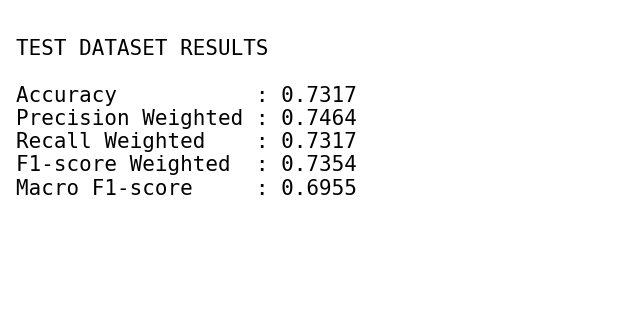

In [ ]:
import matplotlib.pyplot as plt

metrics_text = """
TEST DATASET RESULTS

Accuracy           : 0.7317
Precision Weighted : 0.7464
Recall Weighted    : 0.7317
F1-score Weighted  : 0.7354
Macro F1-score     : 0.6955
"""

plt.figure(figsize=(8, 4))
plt.axis("off")

plt.text(
    0.01,
    0.98,
    metrics_text,
    fontsize=15,
    family="monospace",
    va="top"
)

plt.savefig(
    "test_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

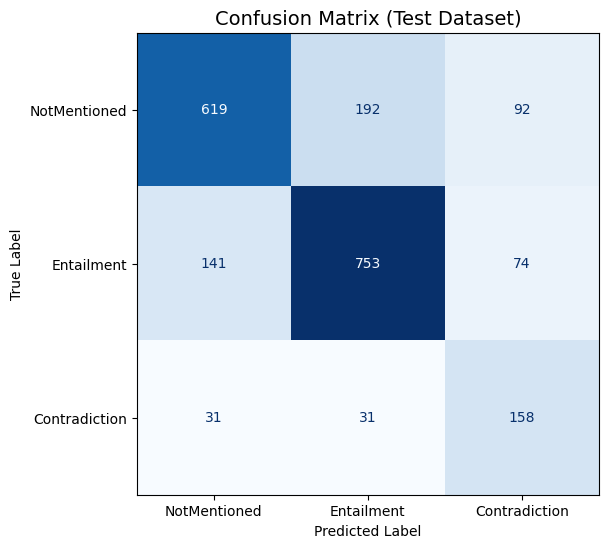

Saved as test_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Test confusion matrix
cm = np.array([
    [619, 192, 92],
    [141, 753, 74],
    [31, 31, 158]
])

labels = ["NotMentioned", "Entailment", "Contradiction"]

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

plt.title("Confusion Matrix (Test Dataset)", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig(
    "test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as test_confusion_matrix.png")

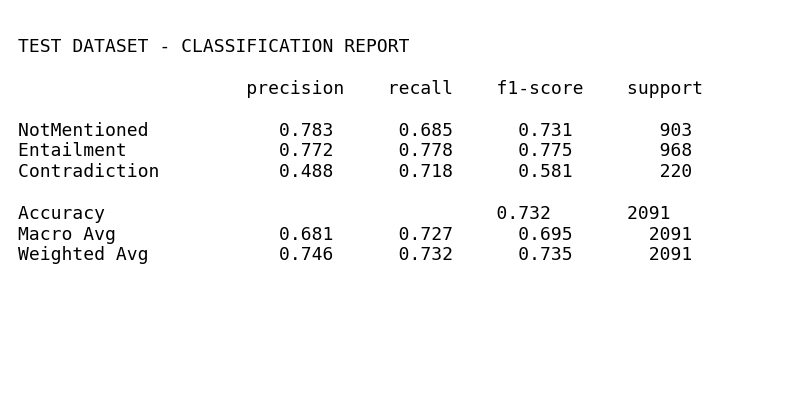

Saved as test_classification_report.png


In [ ]:
import matplotlib.pyplot as plt

report_text = """
TEST DATASET - CLASSIFICATION REPORT

                     precision    recall    f1-score    support

NotMentioned            0.783      0.685      0.731        903
Entailment              0.772      0.778      0.775        968
Contradiction           0.488      0.718      0.581        220

Accuracy                                    0.732       2091
Macro Avg               0.681      0.727      0.695       2091
Weighted Avg            0.746      0.732      0.735       2091
"""

plt.figure(figsize=(10, 5))
plt.axis("off")

plt.text(
    0.01,
    0.98,
    report_text,
    fontsize=13,
    family="monospace",
    va="top"
)

plt.savefig(
    "test_classification_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as test_classification_report.png")